In [5]:
import bilby
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
from lalsimulation import SimNeutronStarEOSByName
import lalsimulation
import sys
import json 
import seaborn as sns
# Create KDE plot for both components
from scipy.stats import gaussian_kde
from scipy.interpolate import interp2d,CloughTocher2DInterpolator

0.9999999961086156


Text(0.5, 0, '$\\Lambda$')

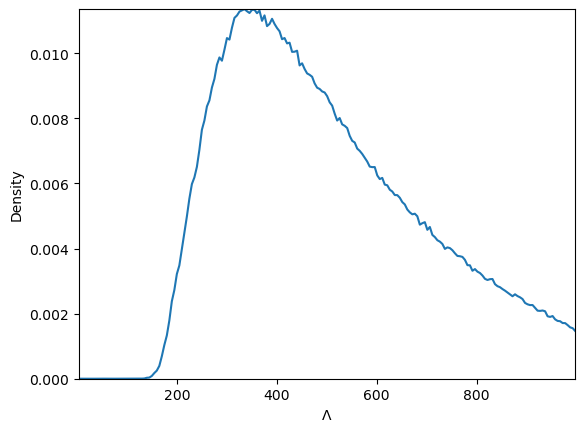

In [6]:
# Read in probability here
# The BNS data without GW constraints
df = pd.read_csv('./MCL_BNS_new.dat',delim_whitespace=True)
#df = df.sort_values(by=[‘mass’])

mass = df['mass'].tolist()

tides = df['tides'].tolist()
prob = df['prob'].tolist()
prob = np.array(prob)
tides = np.array(tides)
mass = np.array(mass)

# Normalise probability 
prob_total2 = sum(prob)
print(prob_total2)
prob2 = np.array(prob)/prob_total2

# Create a grid for the points
points = np.column_stack((mass, tides))
mass_sort2=np.sort(np.unique(mass))
tides_sort2=np.sort(np.unique(tides))

f_interp = CloughTocher2DInterpolator(points,prob)
chirp_mass = 1.2188

y0_tmp = np.tile(chirp_mass,len(tides_sort2))

yy = f_interp(y0_tmp,tides_sort2)
# Normalise 
yy = yy/np.sum(yy)


# Plot the prior for lambda_tilde sliced along the chirp mass of GW170817
plt.plot(tides_sort2,yy)
plt.ylabel('Density')
plt.margins(x=0,y=0)
plt.xlabel(r'$\Lambda$')

In [9]:
# Define chirp mass, mass ratio and eos params
Mchirp = 1.2188
mass_ratio = 0.8
eos_params = [1.0215, 0.1653, -0.0235, -0.0004]

In [12]:
# Calculate prior probability (physics inspired)
f_interp(Mchirp,400)


array(7.14114987e-05)

In [ ]:
# Calculate proability 